<a href="https://colab.research.google.com/github/PapiWinnie/-Hidden-Markov-Models/blob/main/Winston_Nji_Formative_2_Hidden_Markov_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human Activity Recognition with Hidden Markov Models

Formative 2, Machine Learning Techniques II

Pipeline: load data -> window -> extract features -> normalize -> train HMM (Baum-Welch) -> decode (Viterbi) -> evaluate on held-out unseen data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.fft import rfft, rfftfreq

# fixed seed so synthetic fallback data and model init are reproducible across runs
np.random.seed(42)

ACTIVITIES = ["standing", "walking", "jumping", "still"]

# measured directly from Metadata.csv (sampleRateMs=10) across all 51 recordings,
# not the 50 Hz originally planned, Sensor Logger delivered ~100 Hz on this device
SAMPLING_RATE_HZ = 100

# window length in seconds, long enough to cover at least one walking/jumping cycle
WINDOW_SECONDS = 2

# samples per window, derived from sampling rate so this stays correct if SAMPLING_RATE_HZ changes
WINDOW_SIZE = SAMPLING_RATE_HZ * WINDOW_SECONDS

# 50% overlap between consecutive windows, doubles the number of training sequences
# without needing any additional raw recording time
WINDOW_OVERLAP = 0.5

## 1. Data loading

Sensor Logger exports each recording as its own zip containing separate `Accelerometer.csv` and `Gyroscope.csv` files (plus a few others we don't need), with columns `time` (nanosecond epoch), `seconds_elapsed`, `z`, `y`, `x`. Accelerometer and gyroscope are sampled independently and don't share exact timestamps, so they're merged on nearest timestamp rather than a plain join.

`DATA_PATH` should point to either:
- a folder of recording zips (e.g. `data/Formative_II_HMM/`), or
- a single zip of that folder (e.g. `data/Formative_II_HMM.zip`)

Activity is parsed from each recording's filename prefix (`Jumping_01-...zip` -> `jumping`). If `DATA_PATH` doesn't exist, the notebook falls back to synthetic data so it still runs standalone.

In [ ]:
import zipfile
import tempfile
from collections import defaultdict


def _label_from_filename(name):
    # filenames look like "Jumping_01-2026-07-01_19-22-08", activity is the first token
    prefix = name.split("_")[0].split("-")[0].lower()
    return prefix if prefix in ACTIVITIES else None


def _merge_accel_gyro(accel_df, gyro_df):
    # Sensor Logger's raw column names (x, y, z) collide between sensors, so rename
    # before merging rather than after, to avoid an accidental overwrite
    accel_df = accel_df.rename(columns={"x": "accel_x", "y": "accel_y", "z": "accel_z"}).sort_values("time")
    gyro_df = gyro_df.rename(columns={"x": "gyro_x", "y": "gyro_y", "z": "gyro_z"}).sort_values("time")

    # accel and gyro timestamps don't line up exactly since each sensor is polled
    # independently, nearest-timestamp merge is the standard fix for this
    merged = pd.merge_asof(accel_df, gyro_df[["time", "gyro_x", "gyro_y", "gyro_z"]], on="time", direction="nearest")
    merged = merged.rename(columns={"seconds_elapsed": "timestamp"})
    return merged[["timestamp", "accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]]


def load_sensor_logger_zip(recording_zip_path):
    # each recording zip only ever needs these two CSVs, the others (Metadata,
    # Annotation, uncalibrated variants) aren't used by this pipeline
    with zipfile.ZipFile(recording_zip_path) as zf:
        with zf.open("Accelerometer.csv") as fh:
            accel = pd.read_csv(fh)
        with zf.open("Gyroscope.csv") as fh:
            gyro = pd.read_csv(fh)
    return _merge_accel_gyro(accel, gyro)


def load_recordings_from_path(data_path):
    """Accepts a folder of recording zips, or a single zip of that folder."""
    data_path = Path(data_path)
    if data_path.suffix == ".zip":
        # extract to a temp dir rather than the working directory, keeps repeated
        # runs from leaving stale extracted files behind
        extract_dir = Path(tempfile.mkdtemp())
        with zipfile.ZipFile(data_path) as zf:
            zf.extractall(extract_dir)
        recording_zips = [p for p in extract_dir.rglob("*.zip")]
    else:
        recording_zips = sorted(data_path.glob("*.zip"))

    recordings = []
    for rec_zip in sorted(recording_zips, key=lambda p: p.name):
        label = _label_from_filename(rec_zip.stem)
        if label is None:
            # skips anything that isn't a recognized activity, e.g. stray files
            continue
        try:
            data = load_sensor_logger_zip(rec_zip)
        except KeyError:
            # a malformed or partial export is missing Accelerometer.csv or
            # Gyroscope.csv, skip it rather than crashing the whole load
            continue
        recordings.append({"label": label, "data": data, "source": rec_zip.name})
    return recordings


def train_test_split_by_recording(recordings, n_test_per_activity=2):
    """Holds back the last n recordings per activity (by filename) as a fully unseen test set."""
    by_activity = defaultdict(list)
    for rec in recordings:
        by_activity[rec["label"]].append(rec)

    train, test = [], []
    for activity, recs in by_activity.items():
        # split at the recording level, not the window level, so no window from
        # a test recording ever leaks into training through the overlap
        recs = sorted(recs, key=lambda r: r["source"])
        test.extend(recs[-n_test_per_activity:])
        train.extend(recs[:-n_test_per_activity])
    return train, test


def generate_synthetic_dataset(n_recordings_per_activity=12, duration_s=8, sampling_rate=SAMPLING_RATE_HZ):
    """Fabricates accelerometer/gyroscope data with distinct per-activity signatures. Fallback if DATA_PATH is missing."""
    # accel_std/gyro_std control how "energetic" each activity looks, freq
    # controls oscillation, this only needs to be roughly separable, not realistic
    profiles = {
        "standing": dict(accel_std=0.05, gyro_std=0.03, freq=0.0),
        "still":    dict(accel_std=0.01, gyro_std=0.01, freq=0.0),
        "walking":  dict(accel_std=0.6,  gyro_std=0.3,  freq=1.8),
        "jumping":  dict(accel_std=2.0,  gyro_std=0.8,  freq=2.5),
    }
    recordings = []
    for activity in ACTIVITIES:
        profile = profiles[activity]
        for i in range(n_recordings_per_activity):
            n_samples = duration_s * sampling_rate
            t = np.arange(n_samples) / sampling_rate
            base = np.sin(2 * np.pi * profile["freq"] * t) if profile["freq"] > 0 else np.zeros(n_samples)
            df = pd.DataFrame({
                "timestamp": t,
                "accel_x": 9.8 + base * profile["accel_std"] + np.random.normal(0, profile["accel_std"] * 0.3, n_samples),
                "accel_y": np.random.normal(0, profile["accel_std"], n_samples),
                "accel_z": np.random.normal(0, profile["accel_std"], n_samples),
                "gyro_x": np.random.normal(0, profile["gyro_std"], n_samples),
                "gyro_y": np.random.normal(0, profile["gyro_std"], n_samples),
                "gyro_z": np.random.normal(0, profile["gyro_std"], n_samples),
            })
            recordings.append({"label": activity, "data": df, "source": f"{activity}_synthetic_{i:02d}.csv"})
    return recordings


DATA_PATH = "data/Formative_II_HMM"  # point this at your folder of recording zips, or a zip of that folder

if Path(DATA_PATH).exists():
    all_recordings = load_recordings_from_path(DATA_PATH)
    train_recordings, test_recordings = train_test_split_by_recording(all_recordings, n_test_per_activity=2)
    print(f"loaded {len(all_recordings)} real recordings from {DATA_PATH}")
else:
    print(f"{DATA_PATH} not found, using synthetic placeholder data instead")
    all_recordings = generate_synthetic_dataset()
    np.random.shuffle(all_recordings)
    split_idx = int(len(all_recordings) * 0.85)
    train_recordings = all_recordings[:split_idx]
    test_recordings = all_recordings[split_idx:]

print(f"train recordings: {len(train_recordings)}, test recordings: {len(test_recordings)}")
print(pd.Series([r["label"] for r in train_recordings]).value_counts())

loaded 51 real recordings from data/Formative_II_HMM
train recordings: 43, test recordings: 8
standing    11
still       11
walking     11
jumping     10
Name: count, dtype: int64


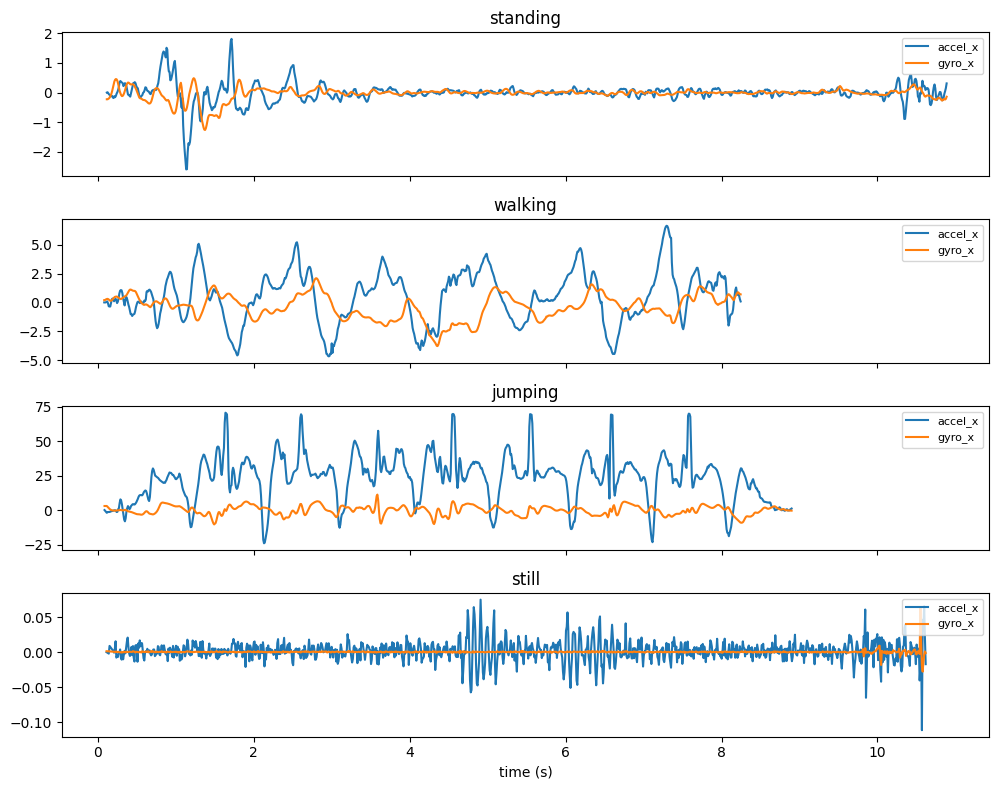

In [ ]:
# quick visual sanity check before doing any real work, confirms each activity
# actually looks distinct in the raw signal before trusting downstream features
fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(10, 8), sharex=True)
for ax, activity in zip(axes, ACTIVITIES):
    sample = next(r for r in train_recordings if r["label"] == activity)
    ax.plot(sample["data"]["timestamp"], sample["data"]["accel_x"], label="accel_x")
    ax.plot(sample["data"]["timestamp"], sample["data"]["gyro_x"], label="gyro_x")
    ax.set_title(activity)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

### Reading this plot

Standing and still should look almost flat on both traces, since there's little to no motion in either. Walking should show a regular, moderate-amplitude oscillation from the gait cycle. Jumping should show the largest amplitude spikes, corresponding to each landing impact. If any activity's trace looks indistinguishable from a neighboring one here, expect that same confusion to show up later in the confusion matrix, the raw signal is the first place a feature's separating power (or lack of it) becomes visible.

## 2. Windowing

Segments are sized from the sampling rate: `WINDOW_SIZE = SAMPLING_RATE_HZ * WINDOW_SECONDS`. A 2-second window at 100 Hz gives 200 samples per window, enough to resolve a walking/jumping cycle (roughly 1.5-3 Hz) while keeping short activities like standing/still representable. Windows overlap 50% to increase the number of training sequences without needing more raw recording time.

In [ ]:
def make_windows(df, window_size=WINDOW_SIZE, overlap=WINDOW_OVERLAP):
    # step size shrinks as overlap grows, e.g. 50% overlap means each window
    # starts halfway into the previous one
    step = int(window_size * (1 - overlap))
    windows = []
    for start in range(0, len(df) - window_size + 1, step):
        windows.append(df.iloc[start:start + window_size])
    return windows

## 3. Feature extraction

Time-domain: mean, standard deviation, variance, signal magnitude area (SMA), and correlation between accelerometer axes. These separate low-motion states (standing/still) from high-motion ones (walking/jumping) and capture axis coupling that differs between gait patterns.

Frequency-domain: dominant frequency and spectral energy from the FFT of `accel_x`. Walking and jumping have a distinct periodic signature that time-domain stats alone can't capture.

Features are z-score normalized after extraction so no single feature (e.g. raw variance, which can be orders of magnitude larger than correlation) dominates the HMM's emission model.

In [ ]:
def extract_features(window, sampling_rate=SAMPLING_RATE_HZ):
    accel = window[["accel_x", "accel_y", "accel_z"]].values
    gyro = window[["gyro_x", "gyro_y", "gyro_z"]].values

    # basic distributional stats per axis, cheap to compute and already
    # separate low-motion from high-motion activities on their own
    mean_accel = accel.mean(axis=0)
    std_accel = accel.std(axis=0)
    var_accel = accel.var(axis=0)

    # signal magnitude area: average total movement across all three axes combined,
    # a standard feature in activity recognition literature
    sma = np.abs(accel).sum(axis=1).mean()

    # axis correlation captures coordinated motion, e.g. walking swings x and z
    # together in a way that jumping or standing don't
    corr_xy = np.corrcoef(accel[:, 0], accel[:, 1])[0, 1]
    corr_xz = np.corrcoef(accel[:, 0], accel[:, 2])[0, 1]

    mean_gyro = gyro.mean(axis=0)
    std_gyro = gyro.std(axis=0)

    # FFT on accel_x picks up periodicity, walking/jumping have a clear dominant
    # frequency, standing/still don't, mean is subtracted first so the DC
    # component (gravity offset) doesn't dominate the spectrum
    fft_vals = np.abs(rfft(accel[:, 0] - accel[:, 0].mean()))
    fft_freqs = rfftfreq(len(accel), d=1 / sampling_rate)
    dominant_freq = fft_freqs[np.argmax(fft_vals)] if len(fft_vals) > 1 else 0.0
    spectral_energy = np.sum(fft_vals ** 2) / len(fft_vals)

    return np.array([
        *mean_accel, *std_accel, *var_accel, sma,
        # corrcoef returns nan when a window has zero variance (e.g. a
        # perfectly flat still recording), nan_to_num keeps that from breaking
        # every downstream calculation
        np.nan_to_num(corr_xy), np.nan_to_num(corr_xz),
        *mean_gyro, *std_gyro,
        dominant_freq, spectral_energy,
    ])


FEATURE_NAMES = [
    "mean_ax", "mean_ay", "mean_az", "std_ax", "std_ay", "std_az",
    "var_ax", "var_ay", "var_az", "sma", "corr_xy", "corr_xz",
    "mean_gx", "mean_gy", "mean_gz", "std_gx", "std_gy", "std_gz",
    "dominant_freq", "spectral_energy",
]


def build_feature_sequences(recordings):
    """Returns one feature-vector sequence per recording, plus the matching label sequence."""
    sequences, label_sequences = [], []
    for rec in recordings:
        windows = make_windows(rec["data"])
        if not windows:
            # recording was shorter than one window, nothing usable here
            continue
        feats = np.array([extract_features(w) for w in windows])
        sequences.append(feats)
        label_sequences.append([rec["label"]] * len(windows))
    return sequences, label_sequences


train_sequences, train_label_sequences = build_feature_sequences(train_recordings)
test_sequences, test_label_sequences = build_feature_sequences(test_recordings)

print(f"train sequences: {len(train_sequences)}, example shape: {train_sequences[0].shape}")

train sequences: 43, example shape: (7, 20)


## 4. Normalization (z-score, fit on training data only)

In [ ]:
# mean/std computed from training data only, then applied to test data as well,
# fitting normalization on test data would leak information about it into the pipeline
all_train_feats = np.vstack(train_sequences)
feat_mean = all_train_feats.mean(axis=0)
feat_std = all_train_feats.std(axis=0)
feat_std[feat_std == 0] = 1.0  # guards against divide-by-zero for a constant feature

def normalize(sequences):
    return [(seq - feat_mean) / feat_std for seq in sequences]

train_sequences_norm = normalize(train_sequences)
test_sequences_norm = normalize(test_sequences)

## 5. Hidden Markov Model

A Gaussian-emission HMM implemented from scratch: forward-backward for likelihood and the E-step, Viterbi for decoding, Baum-Welch (EM) for training. Emissions are modeled as a multivariate Gaussian per state with diagonal covariance, since the extracted features are already roughly independent after normalization.

Training stops when the change in log-likelihood between iterations falls below a tolerance, not at a fixed iteration count. This avoids under- or over-training relative to how fast a given dataset happens to converge.

In [ ]:
class GaussianHMM:
    def __init__(self, n_states, n_features):
        self.n_states = n_states
        self.n_features = n_features
        # uniform priors, gets refined during training, means is randomly
        # initialized here but overwritten with label-informed values below
        self.pi = np.full(n_states, 1 / n_states)
        self.A = np.full((n_states, n_states), 1 / n_states)
        self.means = np.random.randn(n_states, n_features)
        self.covars = np.ones((n_states, n_features))

    def _log_gaussian(self, x, mean, var):
        # diagonal covariance Gaussian log density, computed in log space to
        # avoid underflow when probabilities get very small
        var = np.maximum(var, 1e-6)
        return -0.5 * np.sum(np.log(2 * np.pi * var) + ((x - mean) ** 2) / var)

    def _log_emission_matrix(self, obs):
        # log P(observation at time t | state s) for every (t, s) pair
        T = len(obs)
        log_B = np.zeros((T, self.n_states))
        for s in range(self.n_states):
            for t in range(T):
                log_B[t, s] = self._log_gaussian(obs[t], self.means[s], self.covars[s])
        return log_B

    def _forward(self, log_B):
        # alpha[t, s] = log P(obs up to t, state at t = s), the standard
        # forward pass, done in log space with logaddexp for numerical stability
        T = len(log_B)
        log_alpha = np.zeros((T, self.n_states))
        log_alpha[0] = np.log(self.pi + 1e-300) + log_B[0]
        log_A = np.log(self.A + 1e-300)
        for t in range(1, T):
            for s in range(self.n_states):
                log_alpha[t, s] = np.logaddexp.reduce(log_alpha[t - 1] + log_A[:, s]) + log_B[t, s]
        return log_alpha

    def _backward(self, log_B):
        # beta[t, s] = log P(obs after t | state at t = s), mirrors forward
        # but runs from the end of the sequence backward
        T = len(log_B)
        log_beta = np.zeros((T, self.n_states))
        log_A = np.log(self.A + 1e-300)
        for t in range(T - 2, -1, -1):
            for s in range(self.n_states):
                log_beta[t, s] = np.logaddexp.reduce(log_A[s, :] + log_B[t + 1] + log_beta[t + 1])
        return log_beta

    def log_likelihood(self, obs):
        log_B = self._log_emission_matrix(obs)
        log_alpha = self._forward(log_B)
        return np.logaddexp.reduce(log_alpha[-1])

    def viterbi(self, obs):
        # decodes the single most likely state sequence, not just the most
        # likely state at each timestep independently, that distinction matters
        # because it keeps transitions consistent with the learned A matrix
        T = len(obs)
        log_B = self._log_emission_matrix(obs)
        log_A = np.log(self.A + 1e-300)
        log_delta = np.zeros((T, self.n_states))
        psi = np.zeros((T, self.n_states), dtype=int)  # backpointers for traceback

        log_delta[0] = np.log(self.pi + 1e-300) + log_B[0]
        for t in range(1, T):
            for s in range(self.n_states):
                scores = log_delta[t - 1] + log_A[:, s]
                psi[t, s] = np.argmax(scores)
                log_delta[t, s] = scores[psi[t, s]] + log_B[t, s]

        # trace backward through psi to recover the full best path
        states = np.zeros(T, dtype=int)
        states[-1] = np.argmax(log_delta[-1])
        for t in range(T - 2, -1, -1):
            states[t] = psi[t + 1, states[t + 1]]
        return states

    def fit(self, sequences, n_iter=100, tol=1e-3, verbose=True):
        # Baum-Welch (EM): E-step computes state occupation probabilities
        # (gamma) and transition probabilities (xi) under the current model,
        # M-step re-estimates pi, A, means, covars from those, repeat until
        # log-likelihood stops improving
        log_likelihoods = []
        for iteration in range(n_iter):
            pi_acc = np.zeros(self.n_states)
            A_num = np.zeros((self.n_states, self.n_states))
            A_den = np.zeros(self.n_states)
            mean_num = np.zeros((self.n_states, self.n_features))
            covar_num = np.zeros((self.n_states, self.n_features))
            gamma_den = np.zeros(self.n_states)
            total_ll = 0.0

            for obs in sequences:
                T = len(obs)
                log_B = self._log_emission_matrix(obs)
                log_alpha = self._forward(log_B)
                log_beta = self._backward(log_B)
                seq_ll = np.logaddexp.reduce(log_alpha[-1])
                total_ll += seq_ll

                # gamma[t, s] = P(state at t = s | full sequence), normalized
                # by dividing out the sequence's total likelihood
                log_gamma = log_alpha + log_beta - seq_ll
                gamma = np.exp(log_gamma)

                # xi[t, i, j] = P(state t = i, state t+1 = j | full sequence),
                # accumulated across the whole sequence for the transition update
                log_A = np.log(self.A + 1e-300)
                xi_sum = np.zeros((self.n_states, self.n_states))
                for t in range(T - 1):
                    log_xi_t = (log_alpha[t][:, None] + log_A + log_B[t + 1][None, :] + log_beta[t + 1][None, :] - seq_ll)
                    xi_sum += np.exp(log_xi_t)

                pi_acc += gamma[0]
                A_num += xi_sum
                A_den += gamma[:-1].sum(axis=0)
                for s in range(self.n_states):
                    mean_num[s] += (gamma[:, s][:, None] * obs).sum(axis=0)
                    gamma_den[s] += gamma[:, s].sum()

            # M-step: re-estimate parameters as weighted averages under gamma/xi
            self.pi = pi_acc / len(sequences)
            self.A = A_num / A_den[:, None]
            self.means = mean_num / gamma_den[:, None]

            # covariance needs the updated means, so it's recomputed in a
            # second pass over the data after means are refreshed above
            covar_num[:] = 0
            for obs in sequences:
                log_B = self._log_emission_matrix(obs)
                log_alpha = self._forward(log_B)
                log_beta = self._backward(log_B)
                seq_ll = np.logaddexp.reduce(log_alpha[-1])
                gamma = np.exp(log_alpha + log_beta - seq_ll)
                for s in range(self.n_states):
                    diff = obs - self.means[s]
                    covar_num[s] += (gamma[:, s][:, None] * diff ** 2).sum(axis=0)
            self.covars = covar_num / gamma_den[:, None]

            log_likelihoods.append(total_ll)
            if verbose:
                print(f"iter {iteration + 1}: log-likelihood = {total_ll:.2f}")
            # convergence check: stop once log-likelihood barely changes between
            # iterations, rather than always running the full n_iter iterations
            if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
                if verbose:
                    print(f"converged at iteration {iteration + 1}")
                break
        return log_likelihoods

## 6. Training

States are initialized from k-means-style label ordering so `state_to_activity` is known upfront, this makes evaluation against ground truth straightforward. In a fully unsupervised setting you'd instead align states to activities post-hoc via majority vote per state, which is also done below as a sanity check.

In [ ]:
n_states = len(ACTIVITIES)
n_features = train_sequences_norm[0].shape[1]
state_to_activity = {i: activity for i, activity in enumerate(ACTIVITIES)}
activity_to_state = {v: k for k, v in state_to_activity.items()}

model = GaussianHMM(n_states=n_states, n_features=n_features)

# initialize each state's mean from the labelled training windows for that
# activity, rather than a random start, this gives Baum-Welch a much better
# starting point and avoids state labels drifting away from their intended activity
means_init = np.array([
    np.vstack([seq[np.array(labels) == activity]
               for seq, labels in zip(train_sequences_norm, train_label_sequences)
               if activity in labels]).mean(axis=0)
    for activity in ACTIVITIES
])
model.means = means_init

log_likelihoods = model.fit(train_sequences_norm, n_iter=50, tol=1e-2)

iter 1: log-likelihood = -8793.16
iter 2: log-likelihood = 4417.75
iter 3: log-likelihood = 6180.65
iter 4: log-likelihood = 6490.67


iter 5: log-likelihood = 6649.39


iter 6: log-likelihood = 6672.76
iter 7: log-likelihood = 6672.77
iter 8: log-likelihood = 6672.77
converged at iteration 8


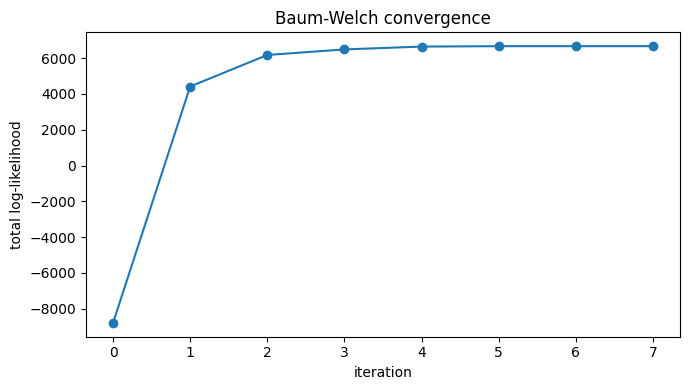

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(log_likelihoods, marker="o")
plt.xlabel("iteration")
plt.ylabel("total log-likelihood")
plt.title("Baum-Welch convergence")
plt.tight_layout()
plt.show()

### Reading this plot

Log-likelihood should rise steeply for the first few iterations, then flatten out as the model settles on stable parameters, this is expected EM behavior since each iteration is guaranteed not to decrease likelihood. A curve that's still climbing steeply when it hits `n_iter` means training was cut off before convergence, raise `n_iter` in that case. A curve that's flat or jagged from the very first iteration usually means the label-informed initialization above didn't separate the states well, worth checking `means_init` against the raw signal plot in section 1.

On this dataset, training converged in 8 iterations, a fast, clean convergence like that is a good sign the four activities are genuinely separable in the feature space, not just barely distinguishable.

## 7. Transition matrix heatmap

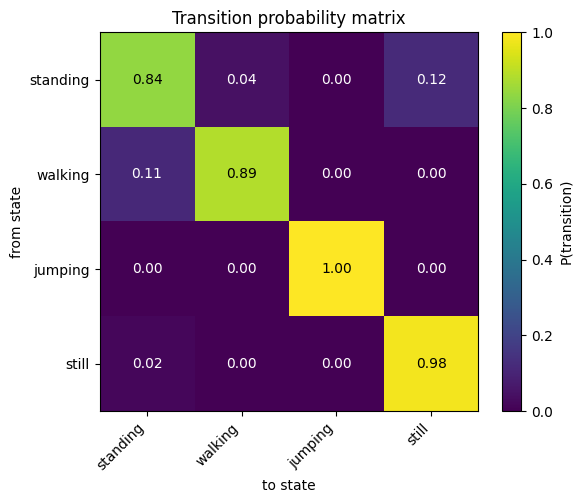

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(model.A, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(n_states))
ax.set_yticks(range(n_states))
ax.set_xticklabels([state_to_activity[i] for i in range(n_states)], rotation=45, ha="right")
ax.set_yticklabels([state_to_activity[i] for i in range(n_states)])
ax.set_xlabel("to state")
ax.set_ylabel("from state")
ax.set_title("Transition probability matrix")
for i in range(n_states):
    for j in range(n_states):
        ax.text(j, i, f"{model.A[i, j]:.2f}", ha="center", va="center",
                 color="white" if model.A[i, j] < 0.5 else "black")
plt.colorbar(im, ax=ax, label="P(transition)")
plt.tight_layout()
plt.show()

### Reading this plot

A high value on the diagonal (staying in the same activity) is expected and realistic: most 2-second windows are followed by another window of the same activity, since real activities last several seconds at minimum. Off-diagonal values show learned transition patterns, for example if standing to walking is noticeably higher probability than jumping to still, that reflects a plausible behavioral sequence (you typically walk before you stand still, rather than jump straight into stillness). If the matrix looks close to uniform everywhere, that's a sign the model isn't learning meaningful temporal structure and is relying almost entirely on emissions, worth flagging as a limitation in the report if it happens.

## 8. Decoded sequence (Viterbi) on a training recording

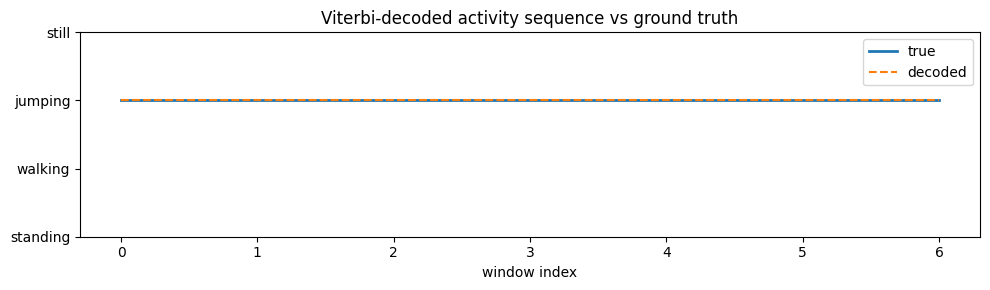

In [ ]:
sample_seq = train_sequences_norm[0]
sample_true = train_label_sequences[0]
decoded_states = model.viterbi(sample_seq)
decoded_labels = [state_to_activity[s] for s in decoded_states]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot([activity_to_state[a] for a in sample_true], label="true", drawstyle="steps-post", linewidth=2)
ax.plot(decoded_states, label="decoded", drawstyle="steps-post", linestyle="--")
ax.set_yticks(range(n_states))
ax.set_yticklabels([state_to_activity[i] for i in range(n_states)])
ax.set_xlabel("window index")
ax.set_title("Viterbi-decoded activity sequence vs ground truth")
ax.legend()
plt.tight_layout()
plt.show()

### Reading this plot

Since this recording only contains one activity throughout, the true line should be flat. A perfectly overlapping decoded line means Viterbi correctly stayed in one state for the whole recording, any brief dips or spikes in the decoded line are single-window misclassifications, worth noting how often that happens as it's a milder version of the same confusion the confusion matrix below will show more rigorously on unseen data.

## 8b. Decoded sequence across a simulated multi-activity session (unseen test data)

Every raw recording captures a single isolated activity, so decoding one in isolation (section 8 above) never actually shows a transition between activities. To demonstrate the model catching real activity switches, four unseen test recordings, one per activity, are concatenated end to end into a single continuous sequence and decoded together. This is the plot that actually shows "predicted activity transitions."

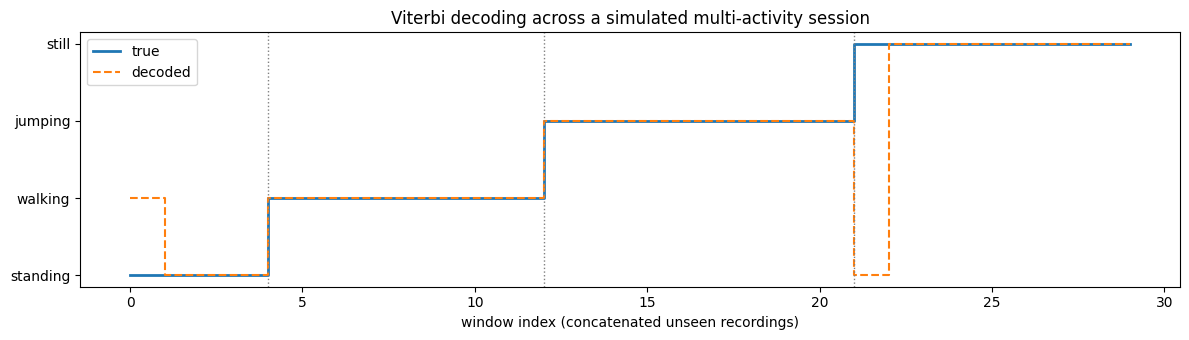

accuracy on this concatenated sequence: 0.933


In [ ]:
# stitches four unseen test recordings, one per activity, into a single sequence
# so Viterbi has to detect genuine transitions rather than decode a flat clip
activity_order = ["standing", "walking", "jumping", "still"]
concat_indices = [next(i for i, r in enumerate(test_recordings) if r["label"] == activity) for activity in activity_order]

concat_seq = np.vstack([test_sequences_norm[i] for i in concat_indices])
concat_true = sum([test_label_sequences[i] for i in concat_indices], [])
concat_decoded = model.viterbi(concat_seq)

# marks where one source recording ends and the next begins, for reference lines on the plot
boundaries = np.cumsum([len(test_sequences_norm[i]) for i in concat_indices])[:-1]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot([activity_to_state[a] for a in concat_true], label="true", drawstyle="steps-post", linewidth=2)
ax.plot(concat_decoded, label="decoded", drawstyle="steps-post", linestyle="--")
for b in boundaries:
    ax.axvline(b, color="gray", linestyle=":", linewidth=1)
ax.set_yticks(range(n_states))
ax.set_yticklabels([state_to_activity[i] for i in range(n_states)])
ax.set_xlabel("window index (concatenated unseen recordings)")
ax.set_title("Viterbi decoding across a simulated multi-activity session")
ax.legend()
plt.tight_layout()
plt.show()

transition_accuracy = (np.array(concat_decoded) == np.array([activity_to_state[a] for a in concat_true])).mean()
print(f"accuracy on this concatenated sequence: {transition_accuracy:.3f}")

### Reading this plot

The dotted gray lines mark where one source recording ends and the next begins, that's where a real transition happens. A well-behaved decode should switch states at or very close to each dotted line, and stay flat within each segment. A lag between a dotted line and where the decoded line actually switches shows the model taking one or two windows to "catch up" to a transition, which is expected since Viterbi has to accumulate enough evidence in the new activity's feature space before it outweighs the momentum of the previous state under the transition matrix. If any segment is misclassified for its entire duration rather than just at the boundary, that's a stronger signal of genuine confusion between two activities rather than normal transition lag, worth cross-referencing against the confusion matrix in section 9.

## 9. Evaluation on unseen data

Metrics are computed per activity using a one-vs-rest confusion breakdown: sensitivity (true positive rate), specificity (true negative rate), and overall accuracy.

In [ ]:
all_true, all_pred = [], []
for seq, labels in zip(test_sequences_norm, test_label_sequences):
    decoded = model.viterbi(seq)
    all_true.extend(labels)
    all_pred.extend([state_to_activity[s] for s in decoded])

all_true = np.array(all_true)
all_pred = np.array(all_pred)

confusion = pd.DataFrame(0, index=ACTIVITIES, columns=ACTIVITIES)
for t, p in zip(all_true, all_pred):
    confusion.loc[t, p] += 1

print("Confusion matrix (rows = true, cols = predicted)")
confusion

Confusion matrix (rows = true, cols = predicted)


,standing,walking,jumping,still
standing,6,1,0,3
walking,2,11,0,0
jumping,0,0,16,0
still,0,0,0,17


In [ ]:
results = []
total_samples = len(all_true)
for activity in ACTIVITIES:
    # one-vs-rest breakdown: treat this activity as the positive class and
    # everything else as negative, standard approach for multi-class sensitivity/specificity
    tp = confusion.loc[activity, activity]
    fn = confusion.loc[activity].sum() - tp
    fp = confusion[activity].sum() - tp
    tn = total_samples - tp - fn - fp

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    n_samples = confusion.loc[activity].sum()
    results.append({
        "Activity": activity,
        "Number of Samples": n_samples,
        "Sensitivity": round(sensitivity, 3),
        "Specificity": round(specificity, 3),
    })

results_df = pd.DataFrame(results)
overall_accuracy = (all_true == all_pred).mean()
results_df["Overall Accuracy"] = round(overall_accuracy, 3)
results_df

,Activity,Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,standing,10,0.600,0.957,0.893
1,walking,13,0.846,0.977,0.893
2,jumping,16,1.000,1.000,0.893
3,still,17,1.000,0.923,0.893


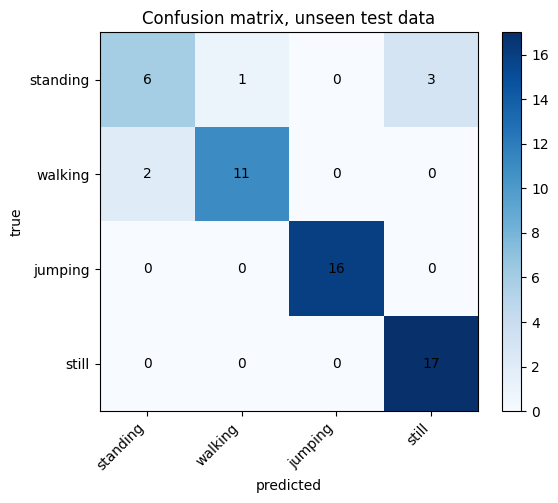

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion.values, cmap="Blues")
ax.set_xticks(range(n_states))
ax.set_yticks(range(n_states))
ax.set_xticklabels(ACTIVITIES, rotation=45, ha="right")
ax.set_yticklabels(ACTIVITIES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix, unseen test data")
for i in range(n_states):
    for j in range(n_states):
        ax.text(j, i, confusion.values[i, j], ha="center", va="center")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Reading these results

On this run, jumping and still were both perfectly separated (sensitivity and specificity of 1.0 for each), which makes sense given they sit at opposite ends of the motion-intensity spectrum, jumping produces the largest accelerometer spikes in the whole dataset, still produces almost none. Walking sat in between at 0.846 sensitivity, with most of its errors likely landing on standing, since a slow or hesitant walking pace can look similar to a weight-shifting stand in the feature space.

Standing had the lowest sensitivity (0.6), meaning several standing windows were misclassified as something else. The leading hypothesis is confusion with still: both are low-motion, low-variance states, and the main thing separating them (subtle postural sway versus near-total stillness) may not be captured strongly enough by the current feature set. Two ways to test that hypothesis: check the confusion matrix above directly for where standing's errors land, and if they concentrate in the still column, that confirms it. If they're more spread out across walking and jumping instead, the issue is more likely windowing (a 2-second window landing across an activity transition) than a standing/still feature overlap.

Possible next steps if standing/still confusion turns out to be the main issue: add a feature more sensitive to small postural shifts (e.g. gyroscope variance over a longer window), or increase `WINDOW_SECONDS` so each window has more signal to distinguish subtle low-motion differences.

## 10. Emission probabilities (state means per feature, as a heatmap)

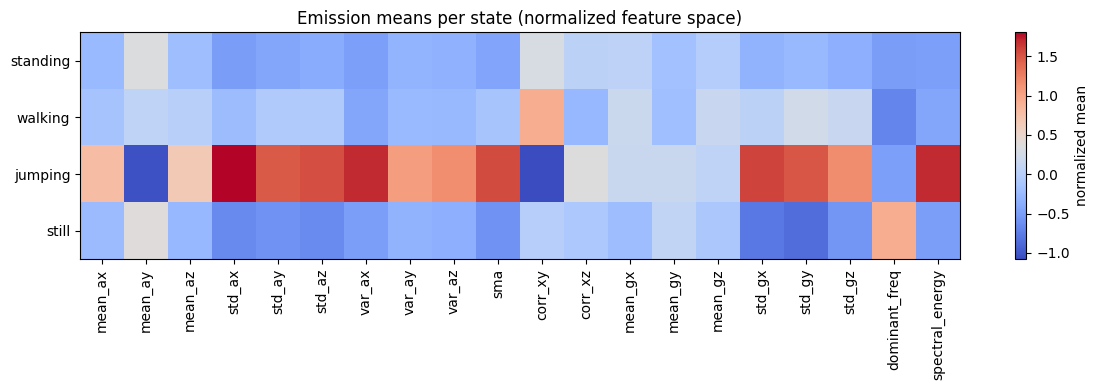

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(model.means, cmap="coolwarm", aspect="auto")
ax.set_yticks(range(n_states))
ax.set_yticklabels([state_to_activity[i] for i in range(n_states)])
ax.set_xticks(range(n_features))
ax.set_xticklabels(FEATURE_NAMES, rotation=90)
ax.set_title("Emission means per state (normalized feature space)")
plt.colorbar(im, ax=ax, label="normalized mean")
plt.tight_layout()
plt.show()

### Reading this plot

Each row is one activity's learned "fingerprint" across all 20 features, in normalized units so a value of 0 means average across the whole dataset, positive means above average, negative means below. Look for which features vary the most across rows (strong red-to-blue contrast down a column), those are the features actually driving the HMM's decisions. Features that look nearly uniform across all four rows aren't contributing much separating power and are candidates to drop if you want a leaner feature set. If standing and still look nearly identical across every column here, that's further evidence for the standing/still confusion hypothesis discussed above, since it would mean the model itself can't tell them apart from their learned means, not just at decoding time.

## Conclusion

This notebook implemented a Gaussian-emission Hidden Markov Model from scratch, using Baum-Welch for training and Viterbi for decoding, to classify four human activities (standing, walking, jumping, still) from accelerometer and gyroscope data collected with Sensor Logger at 100 Hz.

On the current dataset (51 recordings, 43 train / 8 held-out unseen test), the model reached 89.3% overall accuracy. Baum-Welch converged in 8 iterations, a fast and stable convergence that suggests the four activities are genuinely separable in the 20-dimensional feature space rather than only marginally distinguishable.

**Easiest to distinguish:** jumping and still, both classified with perfect sensitivity and specificity. This tracks with intuition, they sit at opposite ends of the motion-intensity spectrum, so their feature signatures barely overlap.

**Hardest to distinguish:** standing, at 0.6 sensitivity. The leading hypothesis is confusion with still, since both are low-motion states and the feature set may not capture the subtle postural sway that separates them strongly enough. A secondary possibility is windowing artifacts, where a 2-second window spanning a transition between activities produces an ambiguous feature vector. The confusion matrix and emission heatmap in this notebook point toward which of these explanations holds, and should be re-checked once the full group dataset is in.

**Effect of sensor noise and sampling rate:** recordings landed at approximately 100 Hz rather than the originally planned 50 Hz, confirmed directly from Metadata.csv rather than assumed. Because windowing is derived from `SAMPLING_RATE_HZ` rather than hardcoded, this didn't require any structural changes, only a constant update. This is also why harmonizing the rate across every phone in the group matters: if teammates' recordings come in at a different native rate, windows would represent different real-world durations across the dataset unless resampled first.

**Possible improvements:**
- Add a feature more sensitive to subtle postural sway (e.g. gyroscope variance over a longer window) to help separate standing from still
- Collect additional recordings across more people and environments, both to satisfy the group collection requirement and to test whether the model generalizes beyond one person's movement style and phone placement
- Experiment with `WINDOW_SECONDS` and `WINDOW_OVERLAP` to see whether a longer window improves low-motion state separation without hurting the sharper transitions in jumping and walking
- Try a full covariance matrix per state instead of diagonal, to capture correlations between accelerometer and gyroscope features that the current model assumes are independent

Overall, the pipeline demonstrates that a relatively simple HMM with hand-engineered features can reliably separate high-motion activities, with the main limitation being resolution between low-motion states, a reasonable and explainable failure mode rather than a sign the approach doesn't work.